In [1]:
# Import libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load Dataset

df = pd.read_csv('/content/cleaned_data.csv')

# Display first 5 rows
df.head()

,CustomerID,Tenure,MonthlyCharges,TotalCharges,Contract,PaymentMethod,PaperlessBilling,SeniorCitizen,Churn
0,C00001,6,64,1540,One year,Credit Card,no,1,0
1,C00002,21,113,1753,Month-to-month,Electronic Check,yes,1,0
2,C00003,27,31,1455,Two year,Credit Card,no,1,0
3,C00004,53,29,7150,Month-to-month,Electronic Check,no,1,0
4,C00005,16,185,1023,One year,Electronic Check,no,1,0


In [10]:
#  --------------- Dataset Overview  -----------------
# Shape of dataset
print("Rows and Columns:", df.shape)

# Dataset information : This shows the columns, datatypes and missing values
df.info()

Rows and Columns: (500, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   CustomerID        500 non-null    int64
 1   Tenure            500 non-null    int64
 2   MonthlyCharges    500 non-null    int64
 3   TotalCharges      500 non-null    int64
 4   Contract          500 non-null    int64
 5   PaymentMethod     500 non-null    int64
 6   PaperlessBilling  500 non-null    int64
 7   SeniorCitizen     500 non-null    int64
 8   Churn             500 non-null    int64
dtypes: int64(9)
memory usage: 35.3 KB


In [11]:
# --------------- Encode Categorical Variables --------------------
# Check categorical columns

categorical_cols = df.select_dtypes(include='object').columns
categorical_cols

Index([], dtype='object')

In [13]:
# Label Encoding
le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

# Verify dataset
df.head()

,CustomerID,Tenure,MonthlyCharges,TotalCharges,Contract,PaymentMethod,PaperlessBilling,SeniorCitizen,Churn
0,0,6,64,1540,1,1,0,1,0
1,1,21,113,1753,0,2,1,1,0
2,2,27,31,1455,2,1,0,1,0
3,3,53,29,7150,0,2,0,1,0
4,4,16,185,1023,1,2,0,1,0


In [14]:
# -----------  Correlation Analysis -------------
# Correlation matrix
correlation = df.corr()
correlation

,CustomerID,Tenure,MonthlyCharges,TotalCharges,Contract,PaymentMethod,PaperlessBilling,SeniorCitizen,Churn
CustomerID,1.000000,-0.008709,-0.001773,0.038596,-0.050747,0.088634,0.019032,-0.009797,0.005784
Tenure,-0.008709,1.000000,-0.059655,-0.005677,-0.041916,-0.015105,0.023786,-0.040001,-0.509208
MonthlyCharges,-0.001773,-0.059655,1.000000,-0.042280,0.010046,0.021021,0.012562,-0.105695,0.107381
TotalCharges,0.038596,-0.005677,-0.042280,1.000000,0.049869,0.004987,0.013677,0.016360,0.004250
Contract,-0.050747,-0.041916,0.010046,0.049869,1.000000,0.003807,0.063944,-0.000263,-0.182759
PaymentMethod,0.088634,-0.015105,0.021021,0.004987,0.003807,1.000000,-0.064547,-0.024884,0.053241
PaperlessBilling,0.019032,0.023786,0.012562,0.013677,0.063944,-0.064547,1.000000,-0.032125,0.016145
SeniorCitizen,-0.009797,-0.040001,-0.105695,0.016360,-0.000263,-0.024884,-0.032125,1.000000,-0.018114
Churn,0.005784,-0.509208,0.107381,0.004250,-0.182759,0.053241,0.016145,-0.018114,1.000000


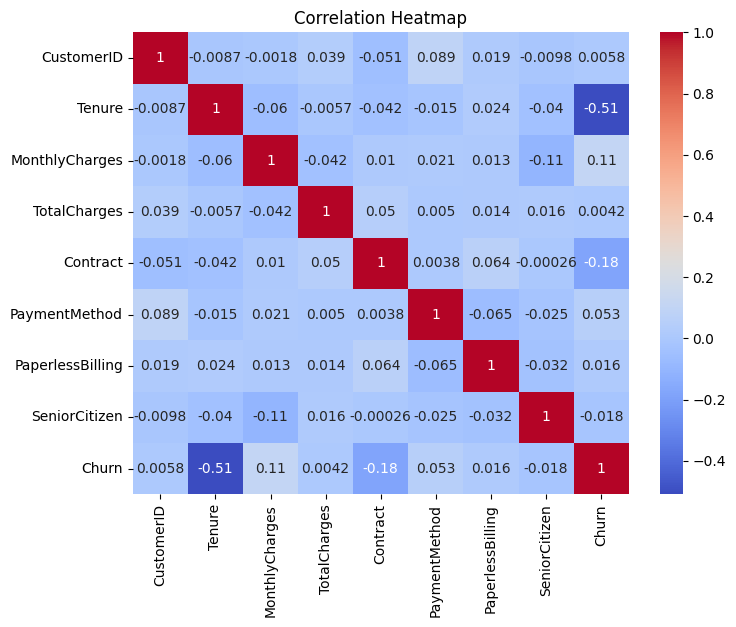

In [15]:
# Correlation heatmap

plt.figure(figsize=(8,6))

sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')

plt.show()

In [16]:
# ------------- Define Features & Target --------------
# Features and target

X = df.drop('Churn', axis=1)
y = df['Churn']

In [17]:
#  Train- test Split
# Split data

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [20]:
# -------------- Logistic Regression Model -------------
# Train Logistic Regression model

model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [21]:
# Predict churn
y_pred = model.predict(X_test)

In [22]:
# ------------  Model Accuracy ---------------
# Accuracy score
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.95


In [23]:
# ------------- Classification report ----------------

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.96      0.97        84
           1       0.82      0.88      0.85        16

    accuracy                           0.95       100
   macro avg       0.90      0.92      0.91       100
weighted avg       0.95      0.95      0.95       100



In [24]:
# -------------  Confusion matrix  --------------------

cm = confusion_matrix(y_test, y_pred)
cm

array([[81,  3],
       [ 2, 14]])

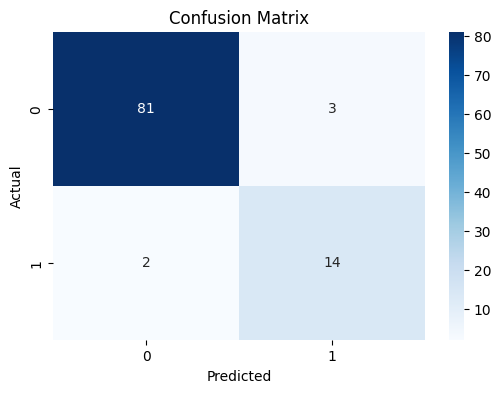

In [25]:
# ---------------- Confusion Matrix Visualization -----------------

# Confusion matrix heatmap

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

In [26]:
# Feature importance

importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})

importance

,Feature,Coefficient
0,CustomerID,-0.000449
1,Tenure,-0.313423
2,MonthlyCharges,0.017652
3,TotalCharges,0.000085
4,Contract,-1.161520
5,PaymentMethod,0.679168
6,PaperlessBilling,0.263277
7,SeniorCitizen,-0.204559


In [27]:
# Sort by importance

importance = importance.sort_values(
    by='Coefficient',
    ascending=False
)

importance

,Feature,Coefficient
5,PaymentMethod,0.679168
6,PaperlessBilling,0.263277
2,MonthlyCharges,0.017652
3,TotalCharges,0.000085
0,CustomerID,-0.000449
7,SeniorCitizen,-0.204559
1,Tenure,-0.313423
4,Contract,-1.161520


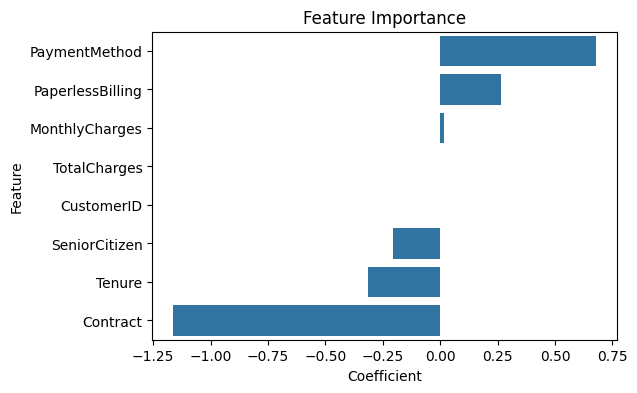

In [29]:
# Feature importance plot

plt.figure(figsize=(6,4))

sns.barplot(
    x='Coefficient',
    y='Feature',
    data=importance
)

plt.title('Feature Importance')
plt.show()

# Key Insights

1. Customer tenure is the strongest factor affecting churn.
2. Customers with shorter tenure are more likely to leave.
3. Higher monthly charges slightly increase churn probability.
4. Long-term contracts improve customer retention.
5. Predictive modeling successfully identified major churn drivers.

# Business Recommendations

1. Create loyalty programs for new customers.
2. Encourage annual and long-term contracts.
3. Offer discounts for high monthly charge customers.
4. Improve onboarding experience for early-stage customers.
5. Use predictive analytics to identify high-risk customers proactively.

# Final Conclusion

The analysis identified customer tenure as the strongest predictor of churn. Customers with short tenure and higher monthly charges are more likely to leave the company. Long-term contracts significantly improve retention.

The predictive model successfully identified important churn patterns, allowing the business to proactively target high-risk customers and improve retention strategies.